# Результаты оценки планнера

Бюджет 1,2 млн ₽, 21 день, цель — конверсии, 8 каналов, случайные события мира выключены, 4 мира (`world_seed` 1–4).
Все режимы одной ячейки идут на одинаковых seed и шоке, поэтому разница между ними объясняется только историей или только режимом исполнения.

Два вопроса и две метрики кейса:

1. **Насколько план попадает в факт** (медиапланер). Меряем при замороженном исполнении: отклонение факта от плана в конце кампании, порог 20 %.
2. **Насколько исполнение удерживает план при шоке** (трафик-менеджер). Меряем парно: тот же план, тот же мир, тот же шок, frozen против adaptive.

Режимы исполнения:
- `frozen` — утверждённые caps не меняются;
- `adaptive` — каждый час факты уходят планнеру; он держит утверждённую смесь, пока прогноз финала на плане, и перекладывает бюджет только чтобы вернуться на план или потратить деньги вставшего канала;
- `adaptive_max` — каждый час максимизирует остаток KPI (прежнее поведение).

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path('.').resolve()
if not (RESULTS / 'runs.json').exists():
    RESULTS = Path('media_planner/tools/evaluation/results')
FIG = RESULTS / 'figures'; FIG.mkdir(exist_ok=True)
pct = lambda x: f'{x:+.0%}'
cold_warm = pd.DataFrame(json.load(open(RESULTS / 'runs.json')))          # каталог против истории (uniform-прогрев)
final = pd.DataFrame(json.load(open(RESULTS / 'tracking' / 'runs.json')))  # три режима, optimized-прогрев
SCENARIOS = ['none', 'ctr_drop', 'cpm_spike', 'supply_drop', 'pause']
SCEN_RU = {'none': 'без шока', 'ctr_drop': 'CTR −40 %', 'cpm_spike': 'CPM +60 %', 'supply_drop': 'спрос −50 %', 'pause': 'пауза 72 ч'}
print(len(cold_warm), 'прогонов cold/warm,', len(final), 'прогонов трёх режимов')

80 прогонов cold/warm, 60 прогонов трёх режимов


## 1. Точность плана: каталог → история кампаний

In [2]:
frozen_none = cold_warm[(cold_warm.scenario == 'none') & (cold_warm['mode'] == 'frozen')]
cold = frozen_none[frozen_none.history == 0].set_index('world_seed').final_dev_kpi
warm_uniform = frozen_none[frozen_none.history == 3].set_index('world_seed').final_dev_kpi
warm_opt = final[(final.scenario == 'none') & (final['mode'] == 'frozen')].set_index('world_seed').final_dev_kpi
table = pd.DataFrame({'каталог': cold, 'история, uniform-прогрев': warm_uniform, 'история, optimized-прогрев': warm_opt})
table.map(pct)

,каталог,"история, uniform-прогрев","история, optimized-прогрев"
world_seed,,,
1,+102%,+18%,+6%
2,+68%,+22%,+6%
3,-26%,+2%,+0%
4,-24%,+8%,+1%


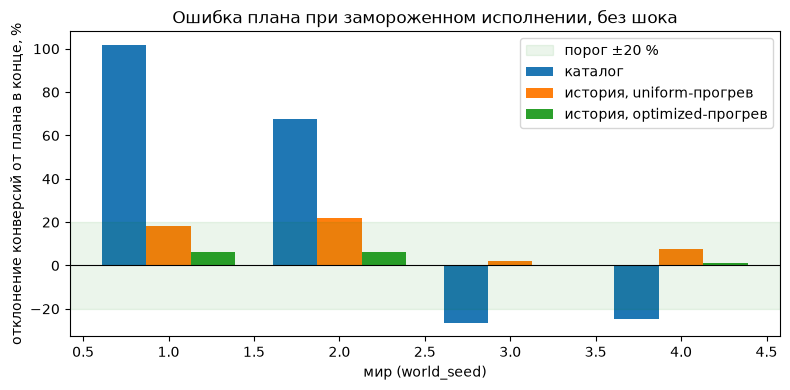

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.26
for i, col in enumerate(table.columns):
    ax.bar(table.index + (i - 1) * width, table[col] * 100, width, label=col)
ax.axhspan(-20, 20, color='green', alpha=0.08, label='порог ±20 %'); ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('мир (world_seed)'); ax.set_ylabel('отклонение конверсий от плана в конце, %')
ax.set_title('Ошибка плана при замороженном исполнении, без шока'); ax.legend()
fig.tight_layout(); fig.savefig(FIG / 'plan_accuracy.png', dpi=120); plt.show()

По каталогу план промахивается на −25…+100 %: это ширина публичных диапазонов, а не ошибка исполнения. История трёх кампаний на том же рынке убирает основную ошибку, а если прошлые кампании были спланированы оптимально (и потому выкупали сильные каналы глубоко), планнер выучивает ещё и параметры насыщения, и ошибка падает до 0–6 %.

## 2. Исполнение при шоках: frozen, adaptive, adaptive_max

In [4]:
g = (final.assign(abs_kpi=final.final_dev_kpi.abs())
         .groupby(['scenario', 'mode'])
         .agg(dev_spend=('final_dev_spend', 'median'), dev_kpi=('final_dev_kpi', 'median'),
              abs_kpi=('abs_kpi', 'median'), reallocated=('reallocated_share', 'median'))
         .reindex(SCENARIOS, level=0).reindex(['frozen', 'adaptive', 'adaptive_max'], level=1))
g.style.format({'dev_spend': pct, 'dev_kpi': pct, 'abs_kpi': '{:.1%}', 'reallocated': '{:.0%}'})

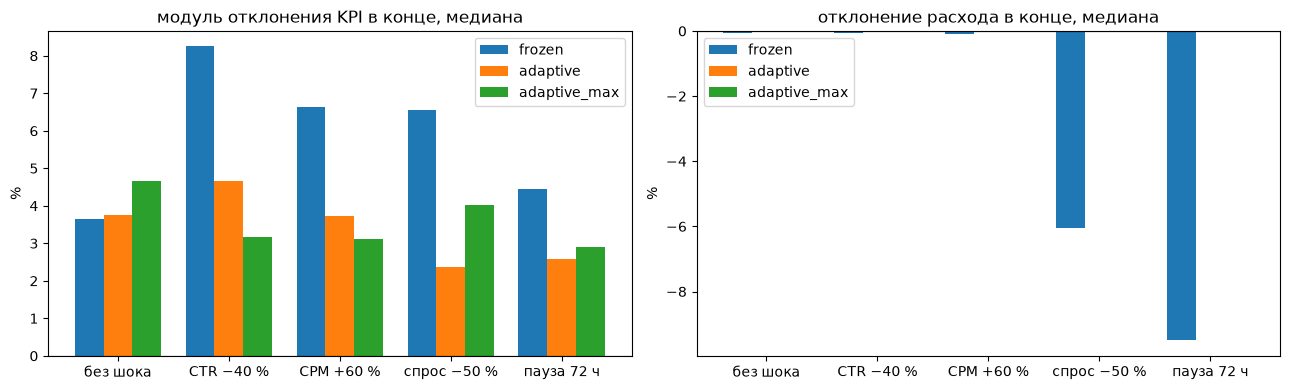

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
modes = ['frozen', 'adaptive', 'adaptive_max']; width = 0.26
for ax, (col, title) in zip(axes, [('abs_kpi', 'модуль отклонения KPI в конце, медиана'), ('dev_spend', 'отклонение расхода в конце, медиана')]):
    for i, m in enumerate(modes):
        vals = [g.loc[(s, m), col] * 100 for s in SCENARIOS]
        ax.bar([k + (i - 1) * width for k in range(len(SCENARIOS))], vals, width, label=m)
    ax.set_xticks(range(len(SCENARIOS))); ax.set_xticklabels([SCEN_RU[s] for s in SCENARIOS])
    ax.axhline(0, color='black', lw=0.8); ax.set_ylabel('%'); ax.set_title(title); ax.legend()
fig.tight_layout(); fig.savefig(FIG / 'modes_by_scenario.png', dpi=120); plt.show()

Читать так:
- **Без шока** `adaptive` неотличим от `frozen` и перекладывает 2 % бюджета; `adaptive_max` перекладывает 30 % и уходит от плана дальше.
- **CTR −40 % и CPM +60 %**: `frozen` недобирает 7–8 %, `adaptive` вдвое меньше, ближе к плану в 4 мирах из 4.
- **Спрос −50 % и пауза**: `frozen` теряет 6–10 % бюджета, `adaptive` дотрачивает в ноль и по KPI ближе к плану там, где план верный.

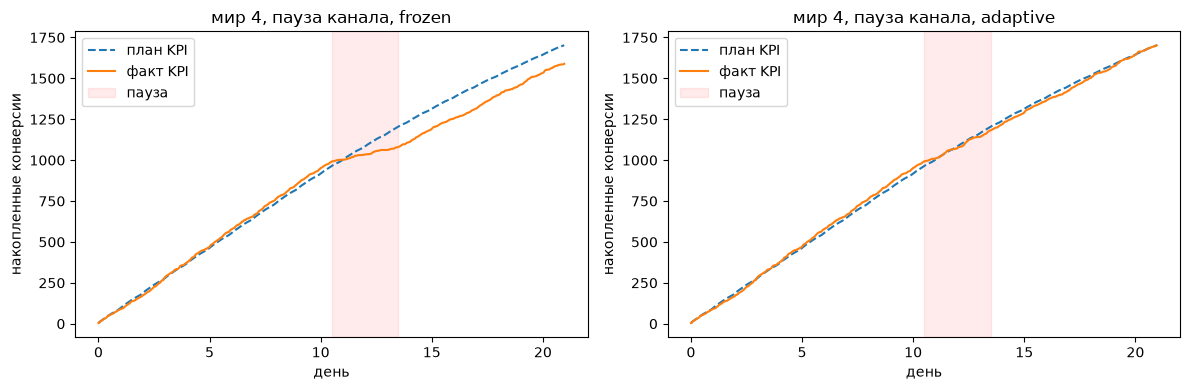

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
def traj(run_id):
    return pd.read_csv(RESULTS / 'tracking' / 'trajectories' / f'{run_id}.csv')
for ax, (mode, title) in zip(axes, [('frozen', 'мир 4, пауза канала, frozen'), ('adaptive', 'мир 4, пауза канала, adaptive')]):
    t = traj(f'w4-c1-h3-pause-{mode}')
    ax.plot(t.hour / 24, t.plan_kpi, '--', label='план KPI'); ax.plot(t.hour / 24, t.fact_kpi, label='факт KPI')
    ax.axvspan(10.5, 13.5, color='red', alpha=0.08, label='пауза'); ax.set_title(title); ax.set_xlabel('день'); ax.set_ylabel('накопленные конверсии'); ax.legend()
fig.tight_layout(); fig.savefig(FIG / 'pause_kpi.png', dpi=120); plt.show()

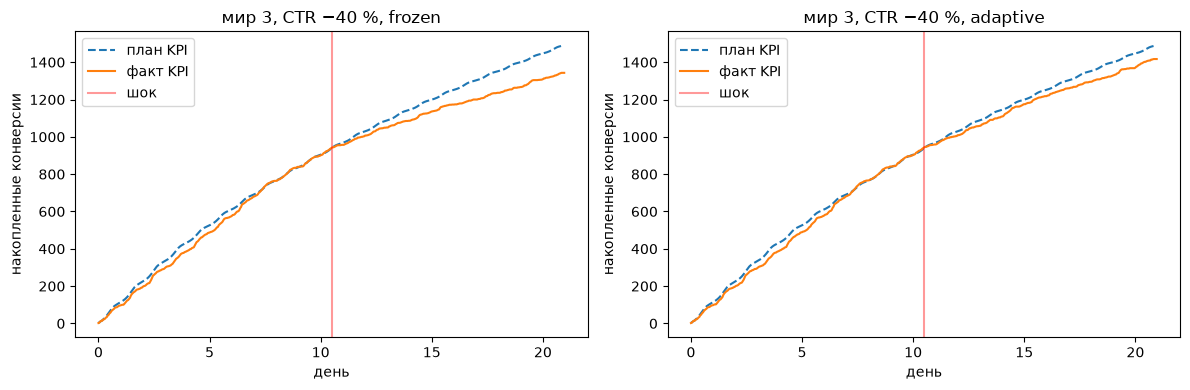

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (mode, title) in zip(axes, [('frozen', 'мир 3, CTR −40 %, frozen'), ('adaptive', 'мир 3, CTR −40 %, adaptive')]):
    t = traj(f'w3-c1-h3-ctr_drop-{mode}')
    ax.plot(t.hour / 24, t.plan_kpi, '--', label='план KPI'); ax.plot(t.hour / 24, t.fact_kpi, label='факт KPI')
    ax.axvline(10.5, color='red', alpha=0.4, label='шок'); ax.set_title(title); ax.set_xlabel('день'); ax.set_ylabel('накопленные конверсии'); ax.legend()
fig.tight_layout(); fig.savefig(FIG / 'ctr_drop_kpi.png', dpi=120); plt.show()

## 3. Парные сравнения по мирам

In [8]:
by = final.set_index(['scenario', 'world_seed', 'mode'])['final_dev_kpi'].abs().unstack('mode')[['frozen', 'adaptive', 'adaptive_max']]
by = by.reindex(SCENARIOS, level=0)
by['adaptive − frozen, п.п.'] = (by['adaptive'] - by['frozen']) * 100
by.style.format({'frozen': '{:.1%}', 'adaptive': '{:.1%}', 'adaptive_max': '{:.1%}', 'adaptive − frozen, п.п.': '{:+.1f}'})

## Выводы

1. Ошибка плана по каталогу — до 2 раз, по истории трёх кампаний — до 6 %. Главное, чему научился планнер, — рынок, а не формулы.
2. Расход держится у плана во всех режимах; провалы `frozen` при паузе и просадке спроса `adaptive` закрывает полностью.
3. При шоках CTR и CPM `adaptive` в 4 мирах из 4 ближе к плану, чем `frozen`, недобор сокращается вдвое. При шоках в 11 парах из 16 строго ближе, в 14 из 16 не хуже.
4. `adaptive_max` даёт сопоставимую близость при шоках, но без шока перекладывает треть бюджета вслед за шумом и уходит от плана дальше. Удержание плана — режим по умолчанию.
5. Оставшийся промах при паузе на мирах 1–2 — след ошибки самого плана (+6 %): дотраченные деньги приносят больше, чем план ожидал.